In [23]:
import numpy as np
import subprocess
import itertools
import re
from scipy.interpolate import RegularGridInterpolator
import astropy.units as u
from astropy.io import fits
from synphot import SourceSpectrum, Observation
from synphot.models import Empirical1D
import multiprocessing as mp
import emcee
import corner

from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

import os
gd_folder = os.getcwd()+"/../../Calculations/SKIRTOR/"

import sys 
sys.path.append(gd_folder)
#from loadSKIRTOR_MRN77 import LoadSKIRTOR_MRN77
from loadSKIRTOR_MRN77_force_reg import LoadSKIRTOR_MRN77
from loadSKIRTOR_General import LoadSKIRTOR_General

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

sys.path.append("../../spec_modeling/")
from model_W0116_spec import model_W0116_spec

In [2]:
#Load the properties of the BHDs
op = ObjectProperties()

In [3]:
#Load the bands.
bands = ReadBands()
for bname in bands.bandnames:
    print(bname, bands.bp[bname].barlam(), bands.bp[bname].fwhm(), bands.bp[bname].rectwidth())

R_SPECIAL 6501.229535920617 Angstrom 1159.881393925198 Angstrom 1624.9974574790472 Angstrom
I_BESS 7925.773360798338 Angstrom 1080.5202412457434 Angstrom 1433.1539789444323 Angstrom
v_HIGH 5531.691038305597 Angstrom 850.6231300284223 Angstrom 1195.0838113345558 Angstrom


In [4]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [5]:
#Read the chi2 maps for each model. To compute the chi^2 map, run the fit_pfrac.ipynb notebook. 
p_map = dict()
chi2_map = dict()
for wid in op.wids:
    fname = "maps/chi2_map_{}.fits".format(wid)
    if os.path.exists(fname):
        h = fits.open(fname)
        tang_grid = np.array(h[0].header['TANGGRID'].split()).astype(float)
        tang_grid = tang_grid * u.Unit(h[0].header['TANGUNIT'])
        cang_grid = np.array(h[0].header['CANGGRID'].split()).astype(float)
        cang_grid = cang_grid * u.Unit(h[0].header['CANGUNIT'])
        iang_grid = np.array(h[0].header['IANGGRID'].split()).astype(float)
        iang_grid = iang_grid * u.Unit(h[0].header['IANGUNIT'])
        chi2_map[wid] = np.ma.zeros((len(tang_grid), len(cang_grid), len(iang_grid)))
        chi2_map[wid][:,:,:] = h[0].data
        chi2_map[wid].mask = h[1].data.astype(bool)
        print(wid, chi2_map[wid][0,0,0])
    else:
        print("Model files not found. Please run the fit_pfrac notebook first.")

W0019-1046 64.60903701329913
W0204-0506 1402.8429752066115
W0220+0137 1226.7955292570675
W0831+0140 346.890625
W0116-0505 4306.388520634797


In [6]:
#Create an interpolation object for each chi2 map. 
chi2_mod = dict()
for wid in op.pfrac.keys():
    chi2_mod[wid] = RegularGridInterpolator((tang_grid.value, cang_grid.value, iang_grid.value), chi2_map[wid], method='linear', bounds_error=False, fill_value=np.inf)

In [12]:
#MCMC
def run_MCMC(x0, nburn=500, nrep=5000, nwalkers=250, ci=68.3, nthread=None, wids=None):
    
    if wids is None:
        wids = list(op.pfrac.keys())

    labels = [
        "Torus Opening Angle",
        "Cone Opening Angle",
    ]
    for wid in wids:
        labels.append("Inclination {}".format(wid))

    ndim = len(x0)
    p0 = x0 + 1e-4 * np.random.randn(nwalkers, ndim)

    mp.set_start_method('fork', force=True)
    if nthread is None:
        nthread = mp.cpu_count()-1

    with mp.Pool(processes=nthread) as pool:
        #Set the sampler
        sampler = emcee.EnsembleSampler(nwalkers, ndim, logprob, args=[wids], pool=pool)

        #Run the burn-in steps
        state = sampler.run_mcmc(p0, nburn, progress=True)
        sampler.reset()

        #Now, run the production step
        sampler.run_mcmc(state, nrep, progress=True)
    flatchain = sampler.get_chain(flat=True)

    #There is an issue with the definitions of the cone angles in the simulations. Overall, the practical effect is we need to add 10 degrees to the value used in the simulations when interpreting it. 
    flatchain[:,1] += 10

    ci_vals = np.percentile(flatchain, [(100-ci)/2, 50, 100 - (100-ci)/2], axis=0)
    #From best-fit (minimum chi^2)
    print("From minimum chi^2")
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], x0[n], x0[n]-ci_vals[0][n], ci_vals[2][n]-x0[n]))
    #print("chi^2: {}".format(chi2_mod(x0)))
    print()

    #From median
    print("From median")
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], ci_vals[1][n], ci_vals[1][n]-ci_vals[0][n], ci_vals[2][n]-ci_vals[1][n]))
    x_median = ci_vals[1]
    #print("chi^2: {}".format(chi2_mod([x_median[0], x_median[1]-10, x_median[2]])))
    print()

    #From mean
    print("From mean")
    x_mean = np.mean(flatchain, axis=0)
    for n in range(len(labels)):
        print("{}: {:.1f} -{:.1f} +{:.1f}".format(labels[n], x_mean[n], x_mean[n]-ci_vals[0][n], ci_vals[2][n]-x_mean[n]))
    #print("chi^2: {}".format(chi2_mod([x_mean[0], x_mean[1]-10, x_mean[2]])))
    print()
    
    truths = np.copy(x0)
    truths[1] += 10
    fig = corner.corner(flatchain, labels=labels, truths=truths)

    return flatchain

In [8]:
def logprob(x, wids):
    chi2_val = 0.
    for iwid, wid in enumerate(wids):
        chi2_val += chi2_mod[wid]([x[0], x[1], x[2+iwid]])
    return -0.5*chi2_val

In [9]:
#Obtain the combined chi2 of the fit. Specifically, we optimize the fit for every objects for a fixed combination of torus and cone openings and generate a chi2 map in this way. 
chi2_all = np.zeros(chi2_map[op.wids[0]].shape[:2])
for wid in op.wids:
    chi2_all += np.min(chi2_map[wid], axis=2)

i, j = np.unravel_index(np.argmin(chi2_all, axis=None), chi2_all.shape)
print("Torus opening: {} Cone opening: {} Combined Chi2: {:.2f}".format(tang_grid[i], cang_grid[j], chi2_all.min()))
for wid in op.wids:
    print("{} Inclination: {} Chi2: {:.2f}".format(wid, iang_grid[np.argmin(chi2_map[wid][i,j])], np.min(chi2_map[wid][i,j])))

Torus opening: 42.5 deg Cone opening: 36.5 deg Combined Chi2: 30.13
W0019-1046 Inclination: 51.5 deg Chi2: 0.00
W0204-0506 Inclination: 84.5 deg Chi2: 0.00
W0220+0137 Inclination: 90.0 deg Chi2: 0.08
W0831+0140 Inclination: 62.5 deg Chi2: 0.02
W0116-0505 Inclination: 73.0 deg Chi2: 30.03


In [10]:
#Set the initial guess from the combined minimum chi^2. 
x0 = np.zeros(2+len(op.pfrac.keys()))
x0[0] = tang_grid[i].value
x0[1] = cang_grid[j].value
for k, wid in enumerate(op.pfrac.keys()):
    x0[2+k] = iang_grid[np.argmin(chi2_map[wid][i,j])].value

100%|██████████| 5000/5000 [03:11<00:00, 26.08it/s]


From minimum chi^2
Torus Opening Angle: 42.5 --2.0 +7.9
Cone Opening Angle: 36.5 --9.6 +11.7
Inclination W0019-1046: 51.5 -1.2 +4.7
Inclination W0204-0506: 84.5 -5.0 +1.8
Inclination W0220+0137: 90.0 -7.8 +-1.1
Inclination W0831+0140: 62.5 -1.2 +2.2
Inclination W0116-0505: 73.0 -1.6 +1.0

From median
Torus Opening Angle: 46.0 -1.4 +4.4
Cone Opening Angle: 47.0 -1.0 +1.1
Inclination W0019-1046: 53.5 -3.1 +2.7
Inclination W0204-0506: 82.5 -3.0 +3.8
Inclination W0220+0137: 86.2 -4.0 +2.7
Inclination W0831+0140: 63.2 -1.9 +1.5
Inclination W0116-0505: 72.9 -1.5 +1.1

From mean
Torus Opening Angle: 47.0 -2.5 +3.3
Cone Opening Angle: 47.1 -1.0 +1.1
Inclination W0019-1046: 53.4 -3.1 +2.7
Inclination W0204-0506: 82.6 -3.1 +3.7
Inclination W0220+0137: 85.5 -3.3 +3.4
Inclination W0831+0140: 62.6 -1.3 +2.1
Inclination W0116-0505: 72.6 -1.3 +1.4



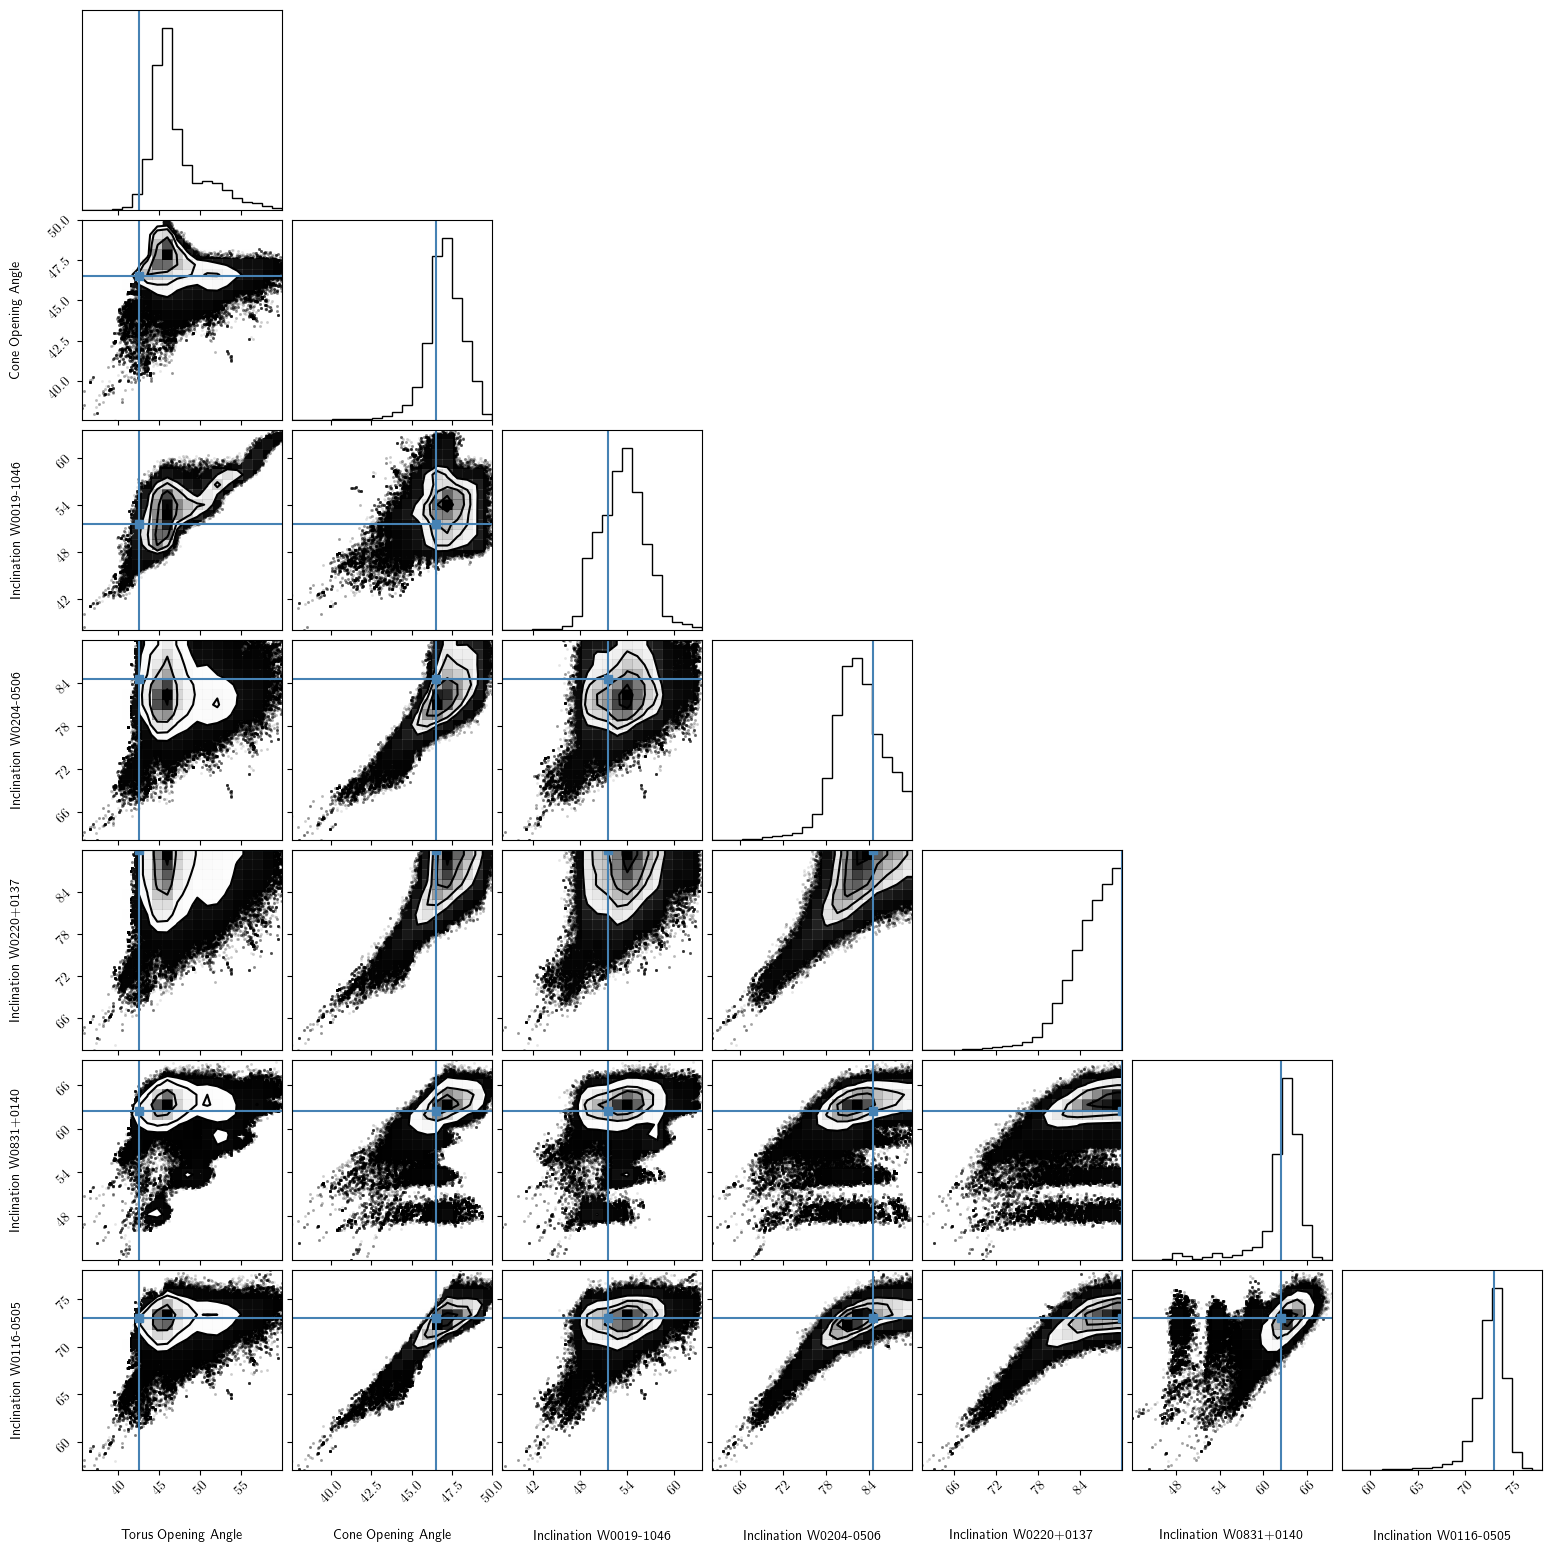

In [13]:
flatchain = run_MCMC(x0)

100%|██████████| 5000/5000 [00:55<00:00, 90.25it/s] 


From minimum chi^2
Torus Opening Angle: 43.0 --4.0 +13.9
Cone Opening Angle: 37.5 --8.9 +13.0
Inclination W0116-0505: 77.0 -4.9 +9.2

From median
Torus Opening Angle: 51.3 -4.3 +5.6
Cone Opening Angle: 48.9 -2.6 +1.6
Inclination W0116-0505: 78.0 -5.9 +8.2

From mean
Torus Opening Angle: 51.6 -4.6 +5.3
Cone Opening Angle: 48.4 -2.0 +2.1
Inclination W0116-0505: 78.5 -6.4 +7.7



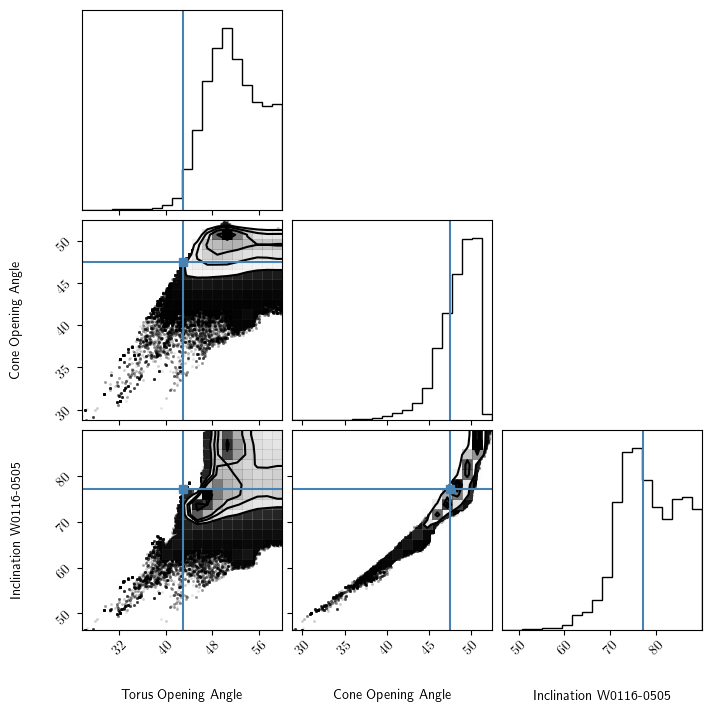

In [15]:
#Now, run the MCMC for W0116 only. 
wid = "W0116-0505"
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
x0_W0116 = np.array([tang_grid[i].value, cang_grid[j].value, iang_grid[k].value])

flatchain_W0116 = run_MCMC(x0_W0116, wids=[wid])

In [20]:
#We need to cut regions that are not allowed from the flatchains. 
flatchain_use = flatchain[flatchain[:,0]>flatchain[:,1]]
flatchain_W0116_use = flatchain_W0116[flatchain_W0116[:,0]>flatchain_W0116[:,1]]

In [33]:
#For the plot, we want to get the upper and lower boundaries of the region to show for W0116.
pw_l = LoadSKIRTOR_MRN77(cone_type='Full', interp_method='linear')
lam_grid = np.arange(1200., 3000., 100.)*u.AA
def mp_func(x):
    results = np.zeros((len(x), len(lam_grid)))
    for rn, xx in enumerate(x):
        results[rn] = 100*pw_l.p((xx[0]*np.ones(lam_grid.shape), (xx[1]-10)*np.ones(lam_grid.shape), xx[2]*np.ones(lam_grid.shape), lam_grid.value))
    return(results)

ci = 99.1
n_threads = mp.cpu_count()-1 #15
splt_flatchain = np.array_split(flatchain_W0116_use, n_threads)

with mp.Pool(processes=n_threads) as pool:
    all_results = pool.map(mp_func, splt_flatchain)
result = np.vstack(all_results)

curve_min, curve_median, curve_max = np.percentile(result, [ (100-ci)/2. , 50, 100 - (100-ci)/2. ], axis=0)

In [22]:
#Set the additional SKIRT models we want to plot for W0116-0505. 
wid = "W0116-0505"
other_sk_models = [
    {"d03_mod":"MW"},
    {"d03_mod":"LMC"},
    {"d03_mod":"SMC"},
    #{"gs_min":0.005, "gs_max":0.25, "a":3.5},
    {"gs_min":1, "gs_max":10, "a":3.5, "sil":True},
    #{"gs_min":0.1, "gs_max":1, "a":0.0},
    #{"gs_min":0.1, "gs_max":1, "a":3.5},
    {"gs_min":0.1, "gs_max":1, "a":3.5, "sil":True},
]


n_mod = len(other_sk_models)
n_band = len(op.pfrac[wid].keys())
n_threads = np.min([mp.cpu_count()-1, n_mod*n_band])
#n_threads = np.min([int(mp.cpu_count()/2), len(other_sk_models)*len(op.pfrac[wid].keys())])
indices = list(itertools.product( np.arange(n_mod) , np.arange(n_band)))
splt_indices = np.array_split(indices, n_threads)

other_sk = list()
for oskm in other_sk_models:
    other_sk.append(LoadSKIRTOR_General(**oskm, interp_method='linear'))

bnames = list(op.pfrac[wid].keys())
def func(x):
    result = np.zeros((n_mod, n_band, len(iang_grid)))
    for ind in x:
        k, j = ind
        bname = bnames[j]
        p_aux = other_sk[k].p_bb(bands.bp[bname], iang_grid, specs.lam_obs[wid], specs.flam[wid], specs.specs.sp[wid].zspec)
        result[k,j] = ((p_aux*100 - op.pfrac[wid][bname])/op.epfrac[wid][bname])**2
    return result

with mp.Pool(processes=n_threads) as pool:
    all_results = pool.map(func, splt_indices)
other_chi2 = (np.sum(all_results, axis=0)).sum(axis=1)


In [27]:
x_best = np.median(flatchain_use, axis=0)
x_best_W0116 = np.median(flatchain_W0116_use, axis=0)
print(x_best_W0116)
print(x0_W0116)

[53.39250643 48.61991325 78.43536379]
[43.  37.5 77. ]


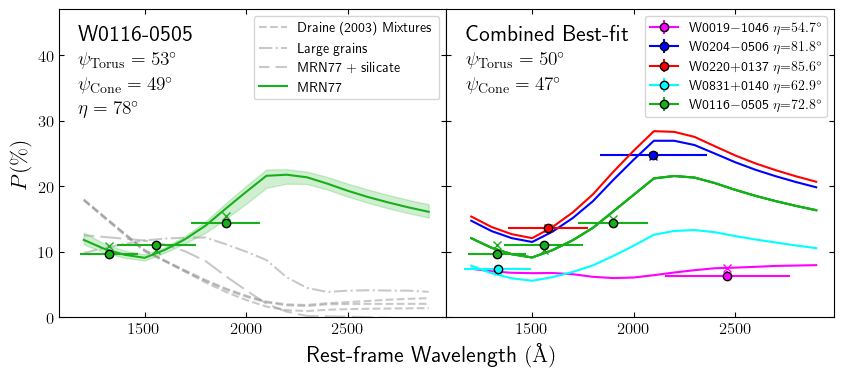

In [37]:
#Plot for the paper.

colors = {"W0116-0505":"xkcd:green", "W0019-1046":"magenta", "W0204-0506":"blue", "W0220+0137":"red", "W0831+0140":"cyan"}

fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0., hspace=0.)

for ax in axs:
    ax.tick_params(axis="both", direction="in", labelsize=12, bottom=True, top=True, left=True, right=True)

#On one plot, we show the best solution for W0116-0505. 
wid = "W0116-0505"

#First plot the range of plaussible models. 
axs[0].fill_between(lam_grid.value, curve_min, curve_max, color=colors[wid], alpha=0.2)

labels = ['Draine (2003) Mixtures', None, None, 'Large grains', 'MRN77 + silicate']
for mm, osk in enumerate(other_sk):
    kk = np.argmin(other_chi2[mm])
    ls = 'dashed'
    if mm==3:
        ls = 'dashdot'
    elif mm==4:
        ls = (5, (10,3))
    elif mm==5:
        ls = 'dotted'
    axs[0].plot(lam_grid, 100*osk.p((iang_grid[kk]*np.ones(lam_grid.shape), lam_grid)), c='xkcd:grey',ls=ls, label=labels[mm], alpha=0.5)

axs[0].plot(lam_grid, 100*pw_l.p((x_best_W0116[0]*np.ones(lam_grid.shape)*u.deg, (x_best_W0116[1]-10)*np.ones(lam_grid.shape)*u.deg, x_best_W0116[2]*np.ones(lam_grid.shape)*u.deg, lam_grid)), c=colors[wid],ls='solid', label='MRN77')

for bname in op.pfrac[wid].keys():

    axs[0].errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', c=colors[wid], markeredgecolor='black')
    p_mod = pw_l.p_bb(bands.bp[bname], [x_best_W0116[0]]*u.deg, [(x_best_W0116[1]-10)]*u.deg, [x_best_W0116[2]]*u.deg, specs.lam_obs[wid], specs.flam[wid], op.z[wid])
    axs[0].plot([bands.bp[bname].barlam().value/(1+op.z[wid])], [p_mod[0,0,0]*100], c=colors[wid], marker='x')

axs[0].text(0.05, 0.9, "W0116-0505", transform=axs[0].transAxes, fontsize=16, weight='bold')
axs[0].text(0.05, 0.82, r"$\psi_{{\rm Torus}} = {:.0f}^{{\circ}}$".format(x_best_W0116[0]), transform=axs[0].transAxes, fontsize=14)
axs[0].text(0.05, 0.74, r"$\psi_{{\rm Cone}}  = {:.0f}^{{\circ}}$".format(x_best_W0116[1]), transform=axs[0].transAxes, fontsize=14)
axs[0].text(0.05, 0.66, r"$\eta = {:.0f}^{{\circ}}$".format(x_best_W0116[2]), transform=axs[0].transAxes, fontsize=14)

axs[0].legend()#loc=(0.45, 0.55))

#On the other, we will show the combined best fit.  
for iwid, wid in enumerate(op.wids):

    for bname in op.pfrac[wid].keys():

        if bname == "R_SPECIAL":
            label = r"{} $\eta$=${:.1f}^{{\circ}}$".format(re.sub("-","$-$",wid), x_best[2+iwid])
        else:
            label = None

        axs[1].plot(lam_grid, 100*pw_l.p((x_best[0]*np.ones(lam_grid.shape)*u.deg, (x_best[1]-10)*np.ones(lam_grid.shape)*u.deg, x_best[2+iwid]*np.ones(lam_grid.shape)*u.deg, lam_grid)), c=colors[wid],ls='solid')

        axs[1].errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', color=colors[wid], markeredgecolor='black', label=label)

        p_mod = pw_l.p_bb(bands.bp[bname], [x_best[0]]*u.deg, [(x_best[1]-10)]*u.deg, [x_best[2+iwid]]*u.deg, specs.lam_obs[wid], specs.flam[wid], op.z[wid])
        axs[1].plot([bands.bp[bname].barlam().value/(1+op.z[wid])], [p_mod[0,0,0]*100], c=colors[wid], marker='x')

axs[1].text(0.05, 0.9, "Combined Best-fit", transform=axs[1].transAxes, fontsize=16, weight='bold')
axs[1].text(0.05, 0.82, r"$\psi_{{\rm Torus}} = {:.0f}^{{\circ}}$".format(x_best[0]), transform=axs[1].transAxes, fontsize=14)
axs[1].text(0.05, 0.74, r"$\psi_{{\rm Cone}}  = {:.0f}^{{\circ}}$".format(x_best[1]), transform=axs[1].transAxes, fontsize=14)
axs[1].legend(loc='upper right')

axs[0].set_ylim([0., 47.])

axs[0].set_ylabel(r"$P (\%)$", fontsize=16)
fig.text(0.5, 0., r"Rest-frame Wavelength $(\rm \AA)$", ha='center', fontsize=16)

fig.savefig("SKIRTOR_MRN77_best-fit_MCMC.png", dpi=100, bbox_inches='tight')
